# Clinical phenotype analysis

This tutorial links a survival phenotype learned from TCGA-BRCA to cell-level spatial expression in HBC1. We identify the highest-scoring malignant epithelial cells, characterize their local microenvironment and molecular program, derive a reference-cohort survival signature, and validate that fixed gene set in independent breast cancer cohorts.

The two expensive discovery products are cached automatically: phenotype scores and differential-expression results are loaded when present and computed only when absent.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root():
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "README.md").exists() and (path / "step1").exists():
            return path
    raise RuntimeError("Please run this notebook from inside the PhenoMap repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from step2.utils.clinical_analysis import (
    define_pr_groups,
    differential_expression,
    evaluate_survival_score,
    fit_repeated_l1_cox,
    load_spatial_expression,
    marker_neighborhoods,
    neighborhood_counts,
    read_expression_rows,
    ssgsea_score,
    xgboost_shap_importance,
)

DATA_ROOT = Path(os.environ["PHENOMAP_DATA_ROOT"]).expanduser().resolve()
HBC1_DIR = DATA_ROOT / "HBC" / "HBC1"
PHENOTYPE_DIR = HBC1_DIR / "phenotype"
OUTPUT_DIR = REPO_ROOT / "outputs" / "04_clinical_phenotype_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TUTORIAL_DIR = REPO_ROOT / "docs" / "source" / "tutorials" / "04_clinical_phenotype_analysis"

BETA_PATH = PHENOTYPE_DIR / "beta_best.parquet"
DEA_PATH = PHENOTYPE_DIR / "DEA_results_best.csv"
SPATIAL_DATA_PATH = HBC1_DIR / "commot_adata_clean.h5ad"
EXPRESSION_PATH = HBC1_DIR / "cell_gene_matrix_filtered.csv"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
    "figure.dpi": 120,
})
warnings.filterwarnings("ignore", message="IProgress not found.*")

COLORS = {"high": "#C84A47", "remaining": "#A7A9AC", "down": "#4C8DAE", "neutral": "#D7D7D7"}

print("PhenoMap environment configured.")


PhenoMap environment configured.


## 1. Load cached phenotype results

`beta_best.parquet` contains the HBC1 cell-level phenotype-relevance (PR) score. If it is missing, the notebook invokes Step 2 with a data-side configuration file named `step2_config.yaml`; an existing score is never retrained.


In [2]:
if BETA_PATH.exists():
    beta = pd.read_parquet(BETA_PATH)
    print("Loaded cached PR-score result.")
else:
    step2_config = PHENOTYPE_DIR / "step2_config.yaml"
    if not step2_config.exists():
        raise FileNotFoundError(
            "PR scores are absent. Add a Step 2 configuration named step2_config.yaml "
            "to the phenotype data directory and rerun this cell."
        )
    subprocess.run(
        [sys.executable, "step2/scripts/train.py", "--config", str(step2_config)],
        cwd=REPO_ROOT,
        check=True,
    )
    beta = pd.read_parquet(BETA_PATH)
    print("Computed and cached PR-score result.")

if beta.columns.tolist() != ["beta"]:
    raise ValueError("Expected beta_best.parquet to contain one column named 'beta'.")

cells, cell_expression = load_spatial_expression(SPATIAL_DATA_PATH, beta)
cells, pr_threshold = define_pr_groups(cells, high_fraction=0.05)
malignant = cells[cells["pr_group"].isin(["PR-high (top 5%)", "Remaining 95%"])].copy()

display(pd.DataFrame({
    "quantity": ["Scored cells", "Malignant epithelial cells", "PR-high malignant cells", "PR-high fraction"],
    "value": [len(cells), len(malignant), malignant["pr_group"].eq("PR-high (top 5%)").sum(), f"{malignant['pr_group'].eq('PR-high (top 5%)').mean():.1%}"],
}))


Loaded cached PR-score result.


,quantity,value
0,Scored cells,110509
1,Malignant epithelial cells,39662
2,PR-high malignant cells,1984
3,PR-high fraction,5.0%


## 2. Map phenotype-associated cells

PR-high cells are defined by rank within malignant epithelial cells: the highest 5% form the phenotype-associated group and the remaining 95% form the comparison group. Ranking selects an exact group size even when scores are tied.


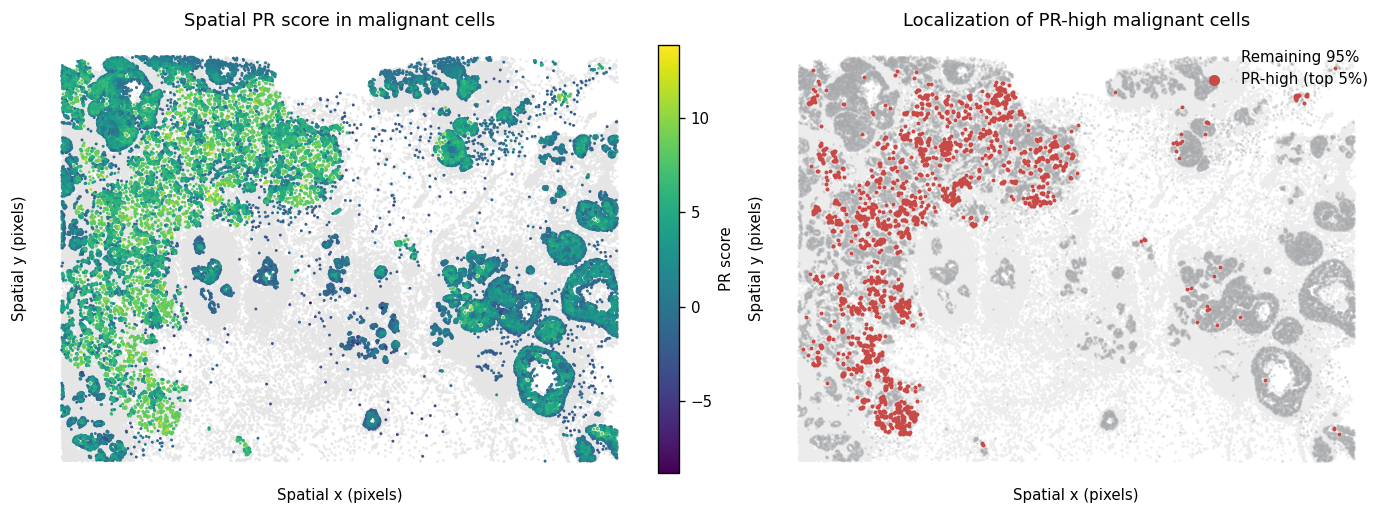

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)

axes[0].scatter(cells["x"], cells["y"], s=0.25, c="#E5E5E5", rasterized=True)
score_points = axes[0].scatter(
    malignant["x"], malignant["y"], c=malignant["beta"], s=0.55,
    cmap="viridis", rasterized=True
)
fig.colorbar(score_points, ax=axes[0], fraction=0.035, pad=0.02, label="PR score")
axes[0].set_title("Spatial PR score in malignant cells")

remaining = malignant[malignant["pr_group"].eq("Remaining 95%")]
high = malignant[malignant["pr_group"].eq("PR-high (top 5%)")]
axes[1].scatter(cells["x"], cells["y"], s=0.25, c="#ECECEC", rasterized=True)
axes[1].scatter(remaining["x"], remaining["y"], s=0.35, c=COLORS["remaining"], alpha=0.28, rasterized=True, label="Remaining 95%")
axes[1].scatter(high["x"], high["y"], s=2.0, c=COLORS["high"], rasterized=True, label="PR-high (top 5%)")
axes[1].set_title("Localization of PR-high malignant cells")
axes[1].legend(markerscale=4, loc="upper right")

for ax in axes:
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("Spatial x (pixels)")
    ax.set_ylabel("Spatial y (pixels)")
    ax.spines[:].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()


The continuous map shows where the survival-associated phenotype is strongest. The second panel isolates the exact top-ranked malignant-cell fraction used in every downstream comparison.


## 3. Characterize local microenvironments

For every malignant-cell centroid, we count T, B, myeloid and stromal cells within a 200-pixel Euclidean radius. Counts are compared with two-sided Mann–Whitney U tests. Marker analyses assign each nearby cell to its nearest PR-high or remaining malignant niche; expression uses a two-sided Mann–Whitney U test and marker-positive fractions use a chi-square test.


In [4]:
RADIUS = 200
niche_counts, niche_tests = neighborhood_counts(cells, radius=RADIUS)
marker_cells, marker_tests = marker_neighborhoods(cells, cell_expression, radius=RADIUS)

niche_display = niche_tests.rename(columns={
    "cell_type": "Cell type",
    "high_mean": "High mean",
    "remaining_mean": "Other mean",
    "p_value": "MWU P",
})[["Cell type", "High mean", "Other mean", "MWU P"]]
marker_display = marker_tests.rename(columns={
    "gene": "Marker",
    "cell_type": "Cell type",
    "high_positive_fraction": "High + (%)",
    "remaining_positive_fraction": "Other + (%)",
    "expression_p": "Expr. MWU P",
    "fraction_chi2_p": "Fraction chi-square P",
})[["Marker", "Cell type", "High + (%)", "Other + (%)", "Expr. MWU P", "Fraction chi-square P"]].copy()
marker_display[["High + (%)", "Other + (%)"]] *= 100

compact_table_styles = [
    {"selector": "table", "props": [("width", "100%"), ("font-size", "0.82rem")]},
    {"selector": "th, td", "props": [("padding", "0.25rem 0.4rem"), ("white-space", "normal")]},
]
display(
    niche_display.style.hide(axis="index")
    .format({"High mean": "{:.2f}", "Other mean": "{:.2f}", "MWU P": "{:.2e}"})
    .set_table_styles(compact_table_styles)
)
display(
    marker_display.style.hide(axis="index")
    .format({
        "High + (%)": "{:.1f}", "Other + (%)": "{:.1f}",
        "Expr. MWU P": "{:.2e}", "Fraction chi-square P": "{:.2e}",
    })
    .set_table_styles(compact_table_styles)
)


Cell type,High mean,Other mean,MWU P
T_cells,0.71,1.44,4.37e-42
B_cells,0.04,0.09,3.70e-10
Myeloid,0.67,1.16,1.50e-41
Stromal,0.70,1.35,4.35e-32


Marker,Cell type,High + (%),Other + (%),Expr. MWU P,Fraction chi-square P
HAVCR2,T_cells,22.2,13.7,5.51e-07,1.35e-06
CD163,Myeloid,77.9,68.0,2.49e-05,2.89e-04
ACTA2,Stromal,94.1,83.4,6.03e-18,4.95e-08


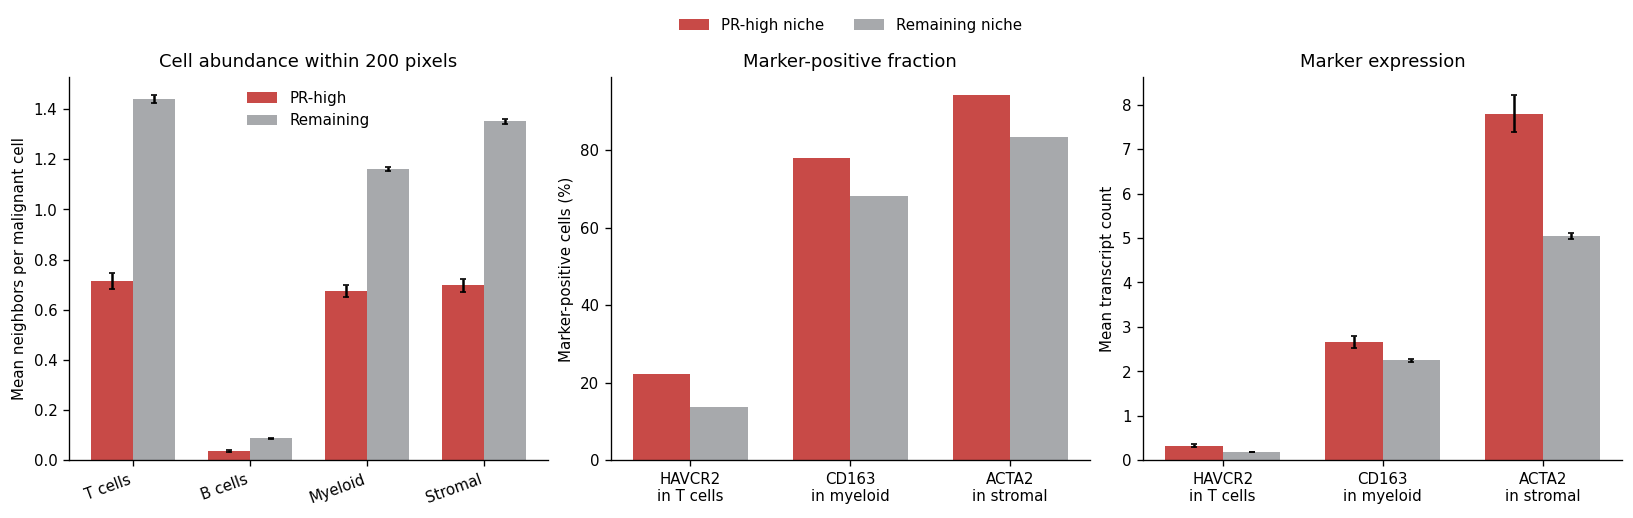

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True)
cell_types = ["T_cells", "B_cells", "Myeloid", "Stromal"]
labels = ["T cells", "B cells", "Myeloid", "Stromal"]
groups = ["PR-high (top 5%)", "Remaining 95%"]
x = np.arange(len(cell_types))
width = 0.36
for offset, group, color, legend in [
    (-width / 2, groups[0], COLORS["high"], "PR-high"),
    (width / 2, groups[1], COLORS["remaining"], "Remaining"),
]:
    subset = niche_counts[niche_counts["pr_group"].eq(group)]
    means = subset.groupby("neighbor_type")["count"].mean().reindex(cell_types)
    sems = subset.groupby("neighbor_type")["count"].sem().reindex(cell_types)
    axes[0].bar(x + offset, means, width, yerr=sems, color=color, label=legend, capsize=2)
axes[0].set_xticks(x, labels, rotation=20, ha="right")
axes[0].set_ylabel("Mean neighbors per malignant cell")
axes[0].set_title("Cell abundance within 200 pixels")
axes[0].legend()

marker_order = ["HAVCR2", "CD163", "ACTA2"]
marker_labels = ["HAVCR2\nin T cells", "CD163\nin myeloid", "ACTA2\nin stromal"]
for offset, group, color, legend in [
    (-width / 2, "PR-high niche", COLORS["high"], "PR-high niche"),
    (width / 2, "Remaining niche", COLORS["remaining"], "Remaining niche"),
]:
    subset = marker_cells[marker_cells["niche"].eq(group)]
    fractions = subset.groupby("gene")["marker_positive"].mean().reindex(marker_order) * 100
    means = subset.groupby("gene")["expression"].mean().reindex(marker_order)
    sems = subset.groupby("gene")["expression"].sem().reindex(marker_order)
    axes[1].bar(np.arange(3) + offset, fractions, width, color=color, label=legend)
    axes[2].bar(np.arange(3) + offset, means, width, yerr=sems, color=color, label=legend, capsize=2)
axes[1].set_xticks(np.arange(3), marker_labels)
axes[1].set_ylabel("Marker-positive cells (%)")
axes[1].set_title("Marker-positive fraction")
axes[2].set_xticks(np.arange(3), marker_labels)
axes[2].set_ylabel("Mean transcript count")
axes[2].set_title("Marker expression")
axes[1].legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.19))
plt.show()


The cell-count panel quantifies the broad composition of each malignant-cell neighborhood. The marker panels add functional resolution by separating the prevalence of marker-positive cells from their expression level.


## 4. Identify phenotype-associated genes

The cached DEA table compares PR-high malignant cells with the remaining malignant cells. If the table is absent, the same grouping is rebuilt from the score and expression matrices, followed by a two-sided Wilcoxon rank-sum test and Benjamini–Hochberg correction. Differentially expressed genes require adjusted *P* < 0.05 and |log2 fold change| > 0.5.


In [6]:
if DEA_PATH.exists():
    dea = pd.read_csv(DEA_PATH)
    print("Loaded cached differential-expression result.")
else:
    raw_expression = pd.read_csv(EXPRESSION_PATH, index_col=0)
    raw_expression.index = raw_expression.index.astype(str)
    malignant_ids = malignant.index.intersection(raw_expression.index)
    dea = differential_expression(
        raw_expression.loc[malignant_ids], malignant.loc[malignant_ids, "pr_group"]
    )
    dea.to_csv(DEA_PATH, index=False)
    print("Computed and cached differential-expression result.")

required_columns = {"names", "scores", "logfoldchanges", "pvals_adj"}
if not required_columns.issubset(dea.columns):
    raise ValueError("The DEA table does not contain the expected columns.")
dea["direction"] = "Not significant"
dea.loc[dea["pvals_adj"].lt(0.05) & dea["logfoldchanges"].gt(0.5), "direction"] = "Up"
dea.loc[dea["pvals_adj"].lt(0.05) & dea["logfoldchanges"].lt(-0.5), "direction"] = "Down"
dea["minus_log10_fdr"] = -np.log10(dea["pvals_adj"].clip(lower=1e-300))

display(dea.groupby("direction").size().rename("genes").reset_index())


Loaded cached differential-expression result.


,direction,genes
0,Down,22
1,Not significant,194
2,Up,96


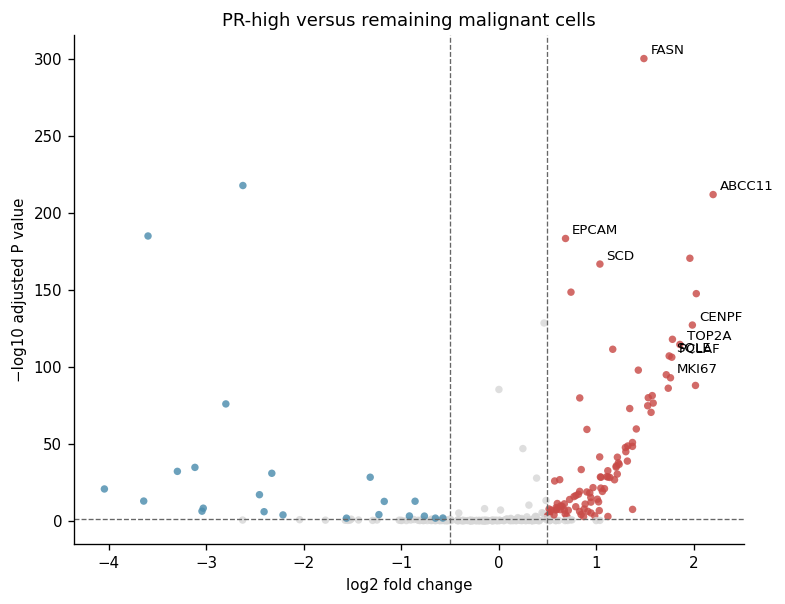

,names,scores,logfoldchanges,pvals_adj,direction
0,FASN,41.73,1.49,0.00e+00,Up
1,ABCC11,31.25,2.20,2.05e-212,Up
2,EPCAM,29.06,0.69,6.76e-184,Up
3,SERHL2,28.02,1.96,4.62e-171,Up
4,SCD,27.70,1.04,2.74e-167,Up
5,FOXA1,26.14,0.74,4.79e-149,Up
6,TENT5C,26.05,2.03,4.42e-148,Up
8,CENPF,24.18,1.99,1.10e-127,Up
311,CEACAM6,-31.70,-2.62,2.75e-218,Down
310,SERPINA3,-29.20,-3.60,1.64e-185,Down


In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.5))
point_colors = dea["direction"].map({"Up": COLORS["high"], "Down": COLORS["down"], "Not significant": COLORS["neutral"]})
ax.scatter(dea["logfoldchanges"], dea["minus_log10_fdr"], c=point_colors, s=20, alpha=0.82, linewidth=0)
ax.axvline(-0.5, color="#666666", lw=0.8, ls="--")
ax.axvline(0.5, color="#666666", lw=0.8, ls="--")
ax.axhline(-np.log10(0.05), color="#666666", lw=0.8, ls="--")
label_genes = ["FASN", "SCD", "SQLE", "ABCC11", "EPCAM", "CENPF", "TOP2A", "PCLAF", "MKI67"]
for gene in label_genes:
    hit = dea[dea["names"].eq(gene)]
    if not hit.empty:
        row = hit.iloc[0]
        ax.annotate(gene, (row["logfoldchanges"], row["minus_log10_fdr"]), xytext=(4, 3), textcoords="offset points", fontsize=8)
ax.set_xlabel("log2 fold change")
ax.set_ylabel("−log10 adjusted P value")
ax.set_title("PR-high versus remaining malignant cells")
plt.show()

top_degs = pd.concat([
    dea[dea["direction"].eq("Up")].nlargest(8, "scores"),
    dea[dea["direction"].eq("Down")].nsmallest(8, "scores"),
])[["names", "scores", "logfoldchanges", "pvals_adj", "direction"]]
display(top_degs.style.format({"scores": "{:.2f}", "logfoldchanges": "{:.2f}", "pvals_adj": "{:.2e}"}))


The volcano plot combines effect size and multiple-testing evidence. Labels are restricted to representative genes that are actually present in the measured panel.


## 5. Rank multivariable biomarkers with XGBoost–SHAP

A class-weighted XGBoost classifier complements one-gene-at-a-time DEA. The positive-class weight is the number of remaining malignant cells divided by the number of PR-high cells; mean absolute SHAP values summarize multivariable importance.


Descriptive training AUC: 0.994


,gene,mean_abs_shap
0,FASN,1.086
1,CEACAM6,0.802
2,KRT7,0.632
3,ERBB2,0.584
4,SCD,0.446
5,SERPINA3,0.424
6,EPCAM,0.381
7,FOXA1,0.257
8,ABCC11,0.238
9,CCND1,0.183


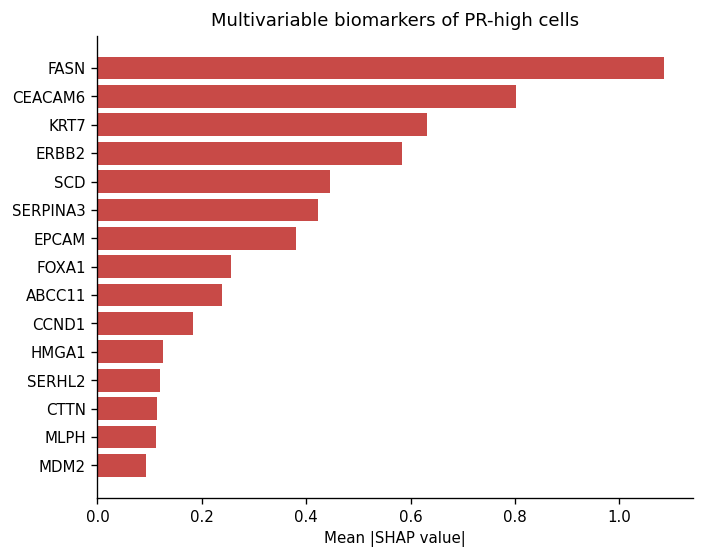

In [8]:
shap_importance, training_auc = xgboost_shap_importance(
    cell_expression.loc[malignant.index], malignant["pr_group"], seed=42
)
print(f"Descriptive training AUC: {training_auc:.3f}")
display(shap_importance.head(15).style.format({"mean_abs_shap": "{:.3f}"}))

top_shap = shap_importance.head(15).sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.barh(top_shap["gene"], top_shap["mean_abs_shap"], color=COLORS["high"])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Multivariable biomarkers of PR-high cells")
plt.show()


The SHAP ranking is descriptive rather than an out-of-sample performance estimate. Its value here is to show which measured genes jointly distinguish the spatially defined phenotype.


### GO Biological Process enrichment

The tutorial ships a compact cache of the study enrichment output so documentation builds do not depend on an external web service. Up- and downregulated programs are displayed separately.


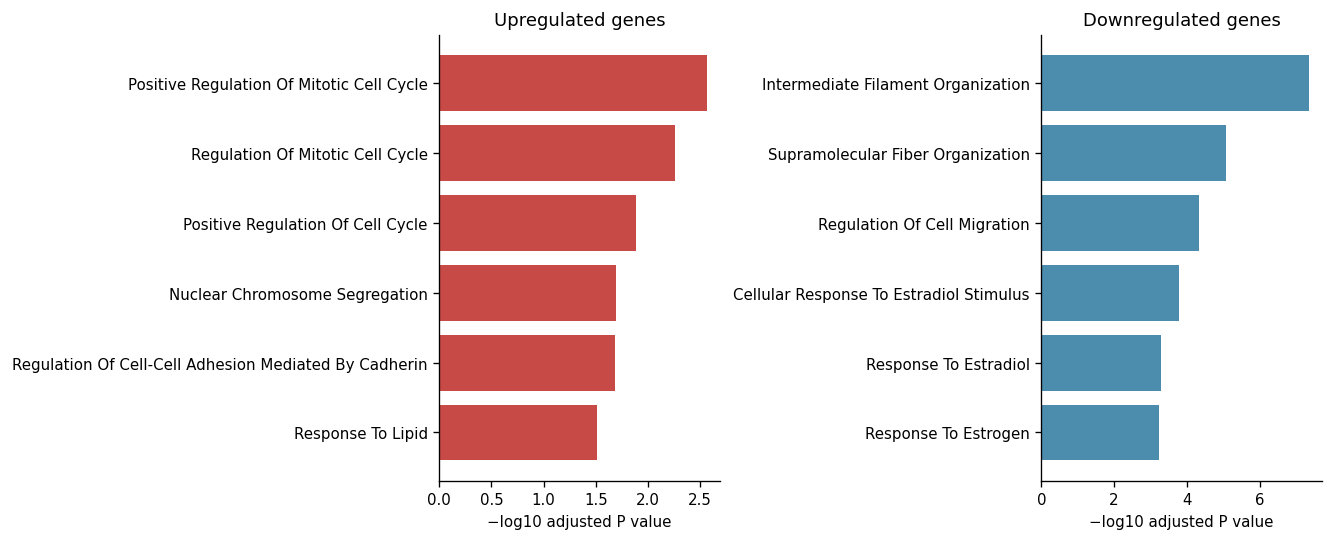

In [9]:
go = pd.read_csv(TUTORIAL_DIR / "go_bp_enrichment.tsv", sep="	")
go = go[go["Adjusted P-value"].lt(0.05)].copy()
go["short_term"] = go["Term"].str.replace(r" \(GO:\d+\)$", "", regex=True)
go["score"] = -np.log10(go["Adjusted P-value"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
for ax, direction, color in zip(axes, ["Up", "Down"], [COLORS["high"], COLORS["down"]]):
    subset = go[go["Direction"].eq(direction)].nlargest(6, "score").sort_values("score")
    ax.barh(subset["short_term"], subset["score"], color=color)
    ax.set_xlabel("−log10 adjusted P value")
    ax.set_title(f"{direction}regulated genes")
plt.show()


The upregulated program emphasizes cell-cycle and lipid-response biology, whereas the downregulated program includes epithelial organization and hormone-response processes.


## 6. Derive the survival signature

Candidates come directly from significant upregulated DEGs, ranked by the DEA statistic and capped at 100 genes. Candidate expression is standardized across TCGA-BRCA patients before fitting an L1-penalized Cox model. Five-fold cross-validation is repeated ten times; the largest penalty within one standard error of the best mean C-index is selected, and only non-zero positive coefficients form the final signature.


In [10]:
up_candidates = (
    dea.loc[dea["direction"].eq("Up")]
    .sort_values("scores", ascending=False)["names"]
    .dropna().astype(str).drop_duplicates().head(100).tolist()
)
TCGA_EXPR_PATH = DATA_ROOT / "HBC" / "TCGA" / "expr_aligned_plus.tsv"
TCGA_CLIN_PATH = DATA_ROOT / "HBC" / "TCGA" / "clinical_aligned_plus.tsv"
tcga_expression = read_expression_rows(TCGA_EXPR_PATH, up_candidates)
tcga_clinical = pd.read_csv(TCGA_CLIN_PATH, sep="	", index_col=0)
signature, cv_diagnostics = fit_repeated_l1_cox(
    tcga_expression, tcga_clinical, up_candidates,
    time_col="OS.time", event_col="OS.event", seed=42,
)
signature.to_csv(OUTPUT_DIR / "breast_survival_signature.csv", index=False)
cv_diagnostics.to_csv(OUTPUT_DIR / "breast_signature_cv.csv", index=False)

summary = cv_diagnostics.attrs
print(f"Eligible DEA candidates: {summary['candidate_count']}")
print(f"Candidates available in TCGA-BRCA: {summary['available_count']}")
print(f"TCGA-BRCA complete cases / events: {summary['patients']} / {summary['events']}")
print(f"Selected positive-coefficient genes: {len(signature)}")
display(signature.style.format({"coefficient": "{:.3f}"}))


Eligible DEA candidates: 96
Candidates available in TCGA-BRCA: 91
TCGA-BRCA complete cases / events: 1080 / 151
Selected positive-coefficient genes: 18


,gene,coefficient
0,EGFL7,0.230
1,EIF4EBP1,0.217
2,SEC24A,0.185
3,RAPGEF3,0.147
4,ZNF562,0.114
5,JUP,0.093
6,C2orf42,0.080
7,LGALSL,0.068
8,BASP1,0.064
9,THAP2,0.061


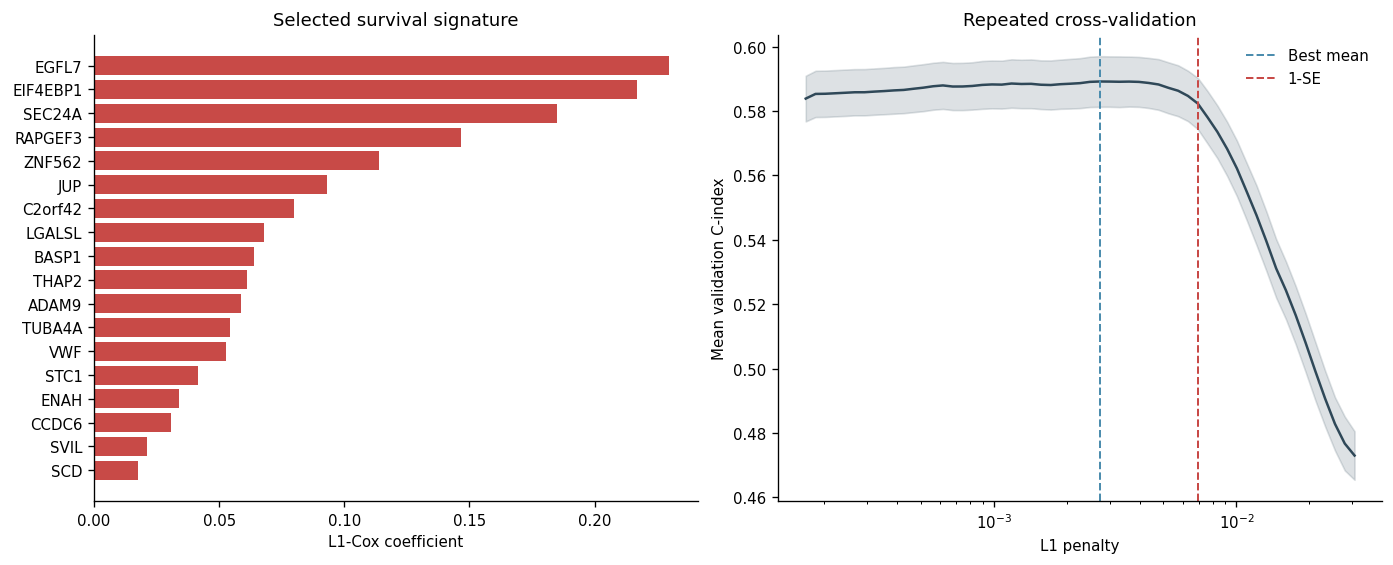

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
coefs = signature.sort_values("coefficient")
axes[0].barh(coefs["gene"], coefs["coefficient"], color=COLORS["high"])
axes[0].set_xlabel("L1-Cox coefficient")
axes[0].set_title("Selected survival signature")

cv_plot = cv_diagnostics.sort_values("alpha")
axes[1].plot(cv_plot["alpha"], cv_plot["mean_cindex"], color="#2F4858", lw=1.5)
axes[1].fill_between(cv_plot["alpha"], cv_plot["mean_cindex"] - cv_plot["se"], cv_plot["mean_cindex"] + cv_plot["se"], color="#2F4858", alpha=0.16)
for column, color, label in [("best_mean", COLORS["down"], "Best mean"), ("one_se", COLORS["high"], "1-SE")]:
    row = cv_plot[cv_plot[column]].iloc[0]
    axes[1].axvline(row["alpha"], color=color, ls="--", lw=1.2, label=label)
axes[1].set_xscale("log")
axes[1].set_xlabel("L1 penalty")
axes[1].set_ylabel("Mean validation C-index")
axes[1].set_title("Repeated cross-validation")
axes[1].legend()
plt.show()


## 7. Validate the signature in external cohorts

The selected gene set is fixed before external analysis. For each cohort, ssGSEA is computed from the genes available on that platform and standardized within the cohort. The primary association is a continuous Cox hazard ratio per one standard-deviation increase; Kaplan–Meier curves use a cohort-median split and a two-sided log-rank test.

We evaluate both overall survival (OS) and metastasis-free survival (MFS) in GSE103091 and GSE7390 using the endpoint columns provided by each cohort's clinical table.


In [12]:
external_specs = [
    {
        "cohort": "GSE103091",
        "expression": DATA_ROOT / "HBC" / "GSE103091" / "expr.tsv",
        "clinical": DATA_ROOT / "HBC" / "GSE103091" / "clinical.tsv",
        "endpoints": [
            {"label": "OS", "time": "OS.time", "event": "OS.event"},
            {"label": "MFS", "time": "MFS.time", "event": "MFS.event"},
        ],
    },
    {
        "cohort": "GSE7390",
        "expression": DATA_ROOT / "HBC" / "GSE7390" / "expr.tsv",
        "clinical": DATA_ROOT / "HBC" / "GSE7390" / "clinical.tsv",
        "endpoints": [
            {"label": "OS", "time": "OS.time", "event": "OS.event"},
            {"label": "MFS", "time": "MFS.time", "event": "MFS.event"},
        ],
    },
]

validation_rows = []
validation_data = {}
for spec in external_specs:
    external_expression = pd.read_csv(spec["expression"], sep="\t", index_col=0)
    external_clinical = pd.read_csv(spec["clinical"], sep="\t", index_col=0)
    score, available = ssgsea_score(external_expression, signature["gene"])
    for endpoint in spec["endpoints"]:
        analysis, result = evaluate_survival_score(
            score,
            external_clinical,
            time_col=endpoint["time"],
            event_col=endpoint["event"],
            time_scale=1 / 30.4375,
        )
        key = (spec["cohort"], endpoint["label"])
        validation_data[key] = (analysis, endpoint["event"])
        validation_rows.append({
            "cohort": spec["cohort"],
            "endpoint": endpoint["label"],
            "available_genes": len(available),
            **result,
        })
    del external_expression

validation = pd.DataFrame(validation_rows)
validation_display = validation.assign(
    HR_CI=validation.apply(
        lambda row: f"{row['hr_per_sd']:.2f} ({row['ci_low']:.2f}–{row['ci_high']:.2f})", axis=1
    )
).rename(columns={
    "cohort": "Cohort", "endpoint": "Endpoint", "available_genes": "Genes",
    "n": "N", "events": "Events", "cox_p": "Cox P", "logrank_p": "Log-rank P",
})[["Cohort", "Endpoint", "Genes", "N", "Events", "HR_CI", "Cox P", "Log-rank P"]]
display(
    validation_display.style.hide(axis="index")
    .format({"Cox P": "{:.2e}", "Log-rank P": "{:.2e}"})
    .set_table_styles(compact_table_styles)
)


Cohort,Endpoint,Genes,N,Events,HR_CI,Cox P,Log-rank P
GSE103091,OS,17,107,29,2.06 (1.32–3.22),1.51e-03,9.43e-04
GSE103091,MFS,17,107,31,2.23 (1.44–3.47),3.59e-04,3.78e-05
GSE7390,OS,16,198,56,1.91 (1.40–2.62),5.42e-05,5.95e-03
GSE7390,MFS,16,198,62,1.77 (1.32–2.37),1.25e-04,2.05e-02


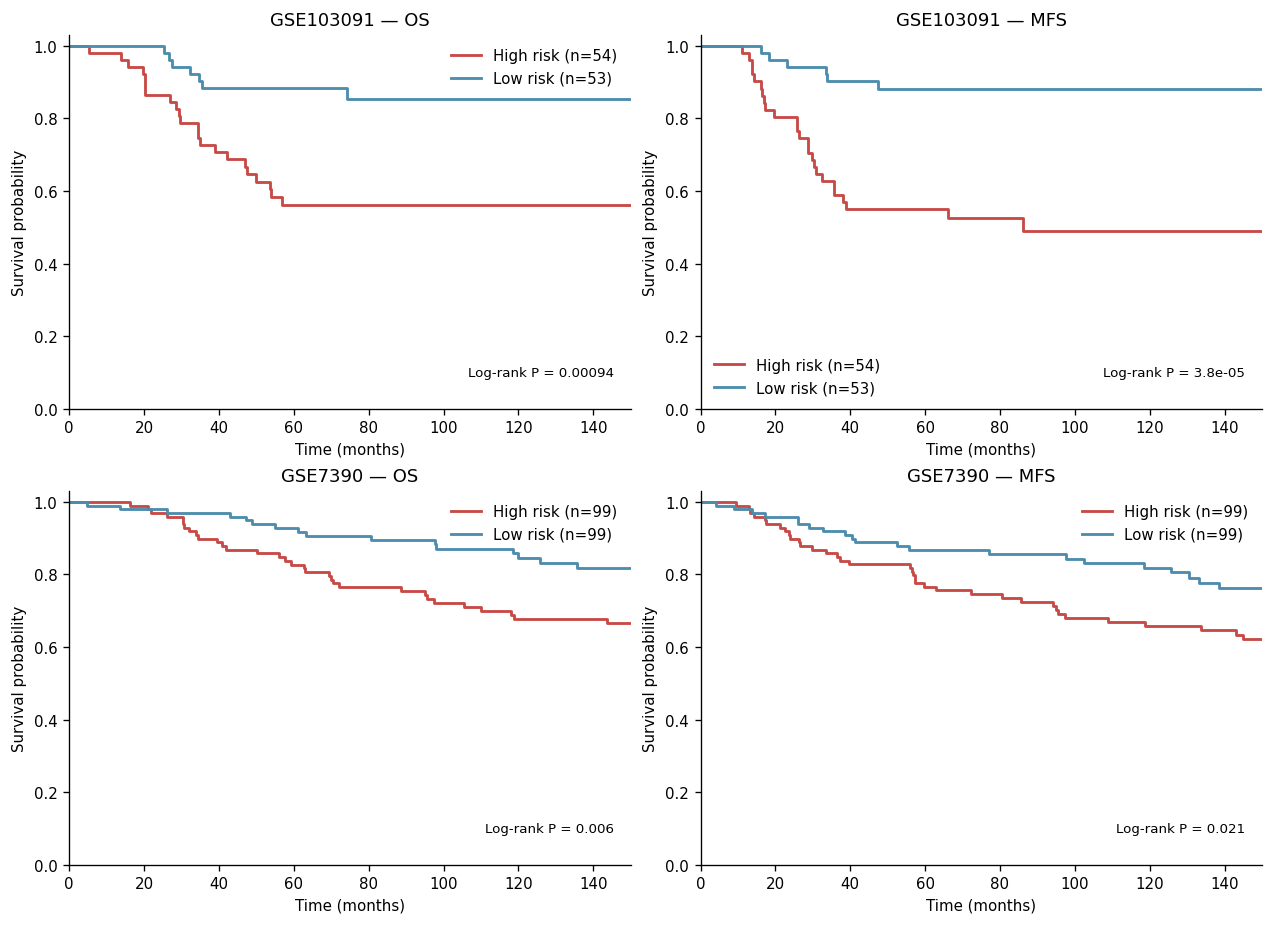

In [13]:
from lifelines import KaplanMeierFitter

plot_order = [
    ("GSE103091", "OS"),
    ("GSE103091", "MFS"),
    ("GSE7390", "OS"),
    ("GSE7390", "MFS"),
]
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.6), constrained_layout=True)
for ax, key in zip(axes.flat, plot_order):
    analysis, event_col = validation_data[key]
    for group, color in [("High", COLORS["high"]), ("Low", COLORS["down"])]:
        subset = analysis[analysis["group"].eq(group)]
        KaplanMeierFitter(label=f"{group} risk (n={len(subset)})").fit(
            subset["time_months"], subset[event_col]
        ).plot_survival_function(ax=ax, ci_show=False, color=color, lw=1.7)
    result = validation.set_index(["cohort", "endpoint"]).loc[key]
    ax.text(
        0.97, 0.08, f"Log-rank P = {result['logrank_p']:.2g}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
    )
    ax.set_title(f"{key[0]} — {key[1]}")
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Survival probability")
    ax.set_xlim(0, 150)
    ax.set_ylim(0, 1.03)
plt.show()


All four panels use the same locked signature and outcome-blinded scoring rule. Curves are displayed through 150 months without confidence bands; platform-specific missing genes are reported explicitly in the table rather than imputed or replaced.


In [14]:
from lifelines import CoxPHFitter

gse7390_analysis, gse7390_event = validation_data[("GSE7390", "OS")]
gse7390_clinical = pd.read_csv(DATA_ROOT / "HBC" / "GSE7390" / "clinical.tsv", sep="	", index_col=0)
gse7390_clinical.index = gse7390_clinical.index.astype(str)
multivariable = gse7390_analysis[["time_months", "score_z"]].join(
    gse7390_clinical[["OS.event", "Tumor_Size", "Grade", "Age"]]
).apply(pd.to_numeric, errors="coerce").dropna()
for column in ["Tumor_Size", "Grade", "Age"]:
    multivariable[column] = (multivariable[column] - multivariable[column].mean()) / multivariable[column].std(ddof=0)
multivariable_fit = CoxPHFitter().fit(multivariable, "time_months", "OS.event")
multivariable_table = multivariable_fit.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
multivariable_table.columns = ["HR", "CI low", "CI high", "P value"]
display(multivariable_table.style.format({"HR": "{:.2f}", "CI low": "{:.2f}", "CI high": "{:.2f}", "P value": "{:.2e}"}))


,HR,CI low,CI high,P value
covariate,,,,
score_z,1.95,1.43,2.66,2.74e-05
Tumor_Size,1.38,1.09,1.75,7.79e-03
Grade,1.02,0.78,1.35,8.67e-01
Age,1.09,0.85,1.40,5.06e-01


## 8. Summary

This workflow starts from a cached cell-level PR score, defines an exact top-5% malignant-cell group, and connects its spatial niche and molecular program to survival. The main safeguards are automatic cache use, one consistent group definition, multiple-testing correction, reference-only penalty selection, and a signature fixed before external validation.
